In [1]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import matplotlib.pyplot as plt
import deeplay as dl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [2]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


In [4]:
data = np.load('D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)
#data = np.load('/home/mph-workstation/simon/2024-03-15/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)

In [5]:
data.keys()

KeysView(NpzFile 'D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz' with keys: E, q, t, n)

In [6]:
data['E'].shape, data['q'].shape, data['t'].shape

((3990, 174, 200), (3990, 4), (3990, 3))

In [7]:
index_min = 0
index_max = 200

EM = data['E'][index_min:index_max]
Q_GT = data['q'][index_min:index_max]
T_GT = data['t'][index_min:index_max]
dRI_GT = data['n'] - 1.33
print(EM.shape)

(200, 174, 200)


In [8]:
dRI_GT.transpose(1, 2, 0).shape

(174, 200, 150)

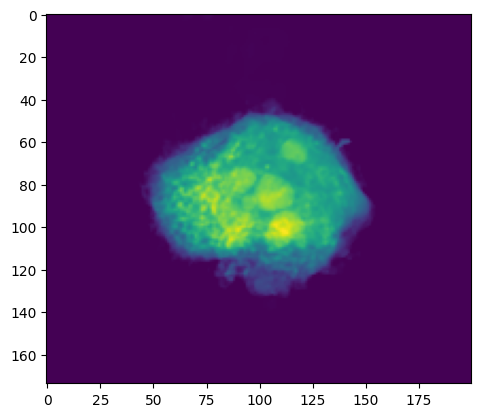

In [9]:
plt.imshow(dRI_GT.transpose(1, 2, 0).sum(axis=-1))

In [10]:
N = 150
EM_crop = np.zeros((200, N, N), dtype=np.complex64)
EM_crop[:] = EM[:, 174//2-N//2:174//2+N//2, 100-N//2:100+N//2] 
dRI_GT_crop = np.zeros((N, N, N), dtype=np.float32)

dRI_GT_crop[:] = dRI_GT.transpose(1, 2, 0)[174//2-N//2:174//2+N//2,100-N//2:100+N//2]

In [11]:
dx, dy, dz = 200e-9, 200e-9, 200e-9
kx, ky = torch.meshgrid([torch.fft.fftfreq(N, d=dx) * 2 * np.pi, torch.fft.fftfreq(N, d=dy) * 2 * np.pi], indexing='ij')
wavelength = 640e-9
n0 = 1.33
k0 = 2 * np.pi / wavelength
se = (k0 * n0)**2 - kx**2 - ky**2
kz = torch.sqrt(se * (se>0)).cuda()

def forward_model(dRI, q, t, K):

    bs = q.shape[0]
    E = torch.ones((bs, N, N), dtype=torch.complex64, device=DEV)
    t_xy = torch.zeros_like(t)
    t_xy[:, :2] = t[:, :2]
    dRI_b = tomographic_model.apply_rotation_batch(dRI, q, t_xy)
    
    for i in range(N):

        E = torch.fft.ifft2(torch.fft.fft2(E, dim=(1, 2)) * K, dim=(1, 2))
        E = E * torch.exp(1j * dRI_b[...,i] * k0 * dz)

    E = torch.fft.ifft2(torch.fft.fft2(E, dim=(1, 2)) * torch.exp(1j * kz * t[:, None, None, 2] * dz), dim=(1, 2)) 
    
    return E * torch.exp(-1j*(N*dz*k0*n0 + t[:, None, None, 2]*dz*k0*n0))
        
def loss_smooth(q, λ1, λ2):

    qd = torch.diff(q, axis=0)
    qdd = torch.diff(qd, axis=0)
    
    return (λ1 * torch.sum(torch.square(qd)) + λ2 * torch.sum(torch.square(qdd))) / q.shape[0]

def loss_TV(a):

    ax = torch.diff(a, axis=0, append=a[-1, None])
    ay = torch.diff(a, axis=1, append=a[:, -1, None])
    az = torch.diff(a, axis=2, append=a[:, :, -1, None])
    beta = 1e-10
    
    return torch.sqrt(ax**2 + ay**2 + az**2 + beta).sum() / a.numel()
    

def loss_data(E, EM):

    return torch.square(torch.abs(E - EM)).mean()



In [12]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# Setup the optics
optics_settings = setup_optics(
        nsize=N, 
        padding_xy=0, 
        microscopy_regime='Brightfield', 
        NA=1.15, 
        wavelength=640e-9, 
        resolution=200e-9, 
        magnification=1, 
        return_field=True)

# Generate the imaging model
brightfield_model = imaging_model(optics_setup=optics_settings)

In [13]:
# Create the tomographic_model
tomographic_model = tomodpdt.Tomography(
    volume_size=(N, N, N), # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='quaternion', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model,
    translation_maxmin=10.0)

In [14]:
from skimage.restoration import unwrap_phase
from scipy.signal import find_peaks

In [15]:
PU = [unwrap_phase(np.angle(E)) for E in EM_crop]

In [16]:
def calc_cc(a, b):
    return np.abs(np.fft.ifft2(np.fft.fft2(a) * np.fft.fft2(b))).max()

In [17]:
cc = []
for i in range(0, 200):
    cc.append(calc_cc(PU[0], PU[i]))
cc = np.array(cc)

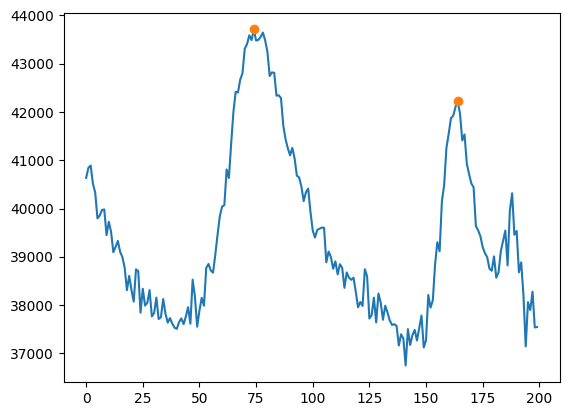

In [18]:
pks = find_peaks(cc, width=10)[0]

plt.plot(cc)
plt.plot(pks, cc[pks], 'o')

In [19]:
pks

array([ 74, 164], dtype=int64)

In [20]:
th = np.array([0.])
for i, pk in enumerate(pks):
    th = np.r_[th, np.linspace(i*np.pi, (i+1)*np.pi, (pks[i] - pks[i-1]) + 1 if i>0 else pks[i])[1:]]
th = np.r_[th, np.linspace((i+1)*np.pi, (i+1)*np.pi + np.pi * ((200 - pks[i]) / (pks[i] - pks[i-1])) , 200 - pks[i] + 1)[1:]]

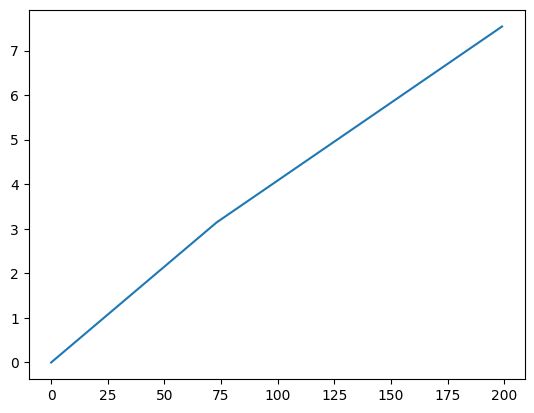

In [21]:
plt.plot(th)

In [22]:
2.3*np.pi

7.225663103256523

In [23]:
Q_GT_new = np.zeros_like(Q_GT)
Q_GT_new[:, 0] = Q_GT[:, 0]
Q_GT_new[:, 1] = -Q_GT[:, 2]
Q_GT_new[:, 2] = -Q_GT[:, 3]
Q_GT_new[:, 3] = -Q_GT[:, 1]

T_GT_new = np.zeros_like(T_GT)
T_GT_new[:, 0] = T_GT[:, 1] / dx
T_GT_new[:, 1] = T_GT[:, 2] / dx
T_GT_new[:, 2] = (T_GT[:, 0] - 150 * dx / 2) / dx

#th = np.linspace(0, 2.3 * np.pi, 200)
Q_start = np.zeros_like(Q_GT_new)
Q_start[:, 0] = np.cos(-th/2)
Q_start[:, 2] = np.sin(-th/2)

T_start = np.zeros_like(T_GT_new)
T_start[:, 2] = - 40.

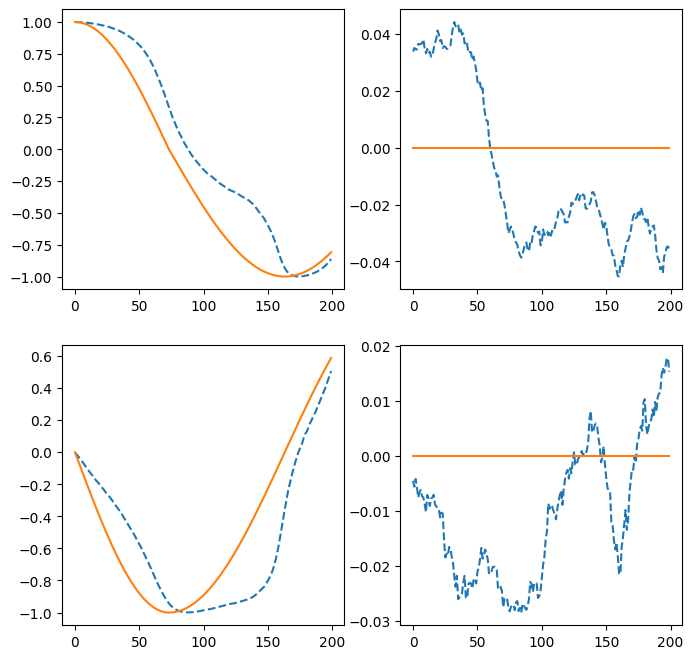

In [24]:
plt.figure(figsize=(8, 8))
for i in range(4):
    plt.subplot(2, 2, i+1) 
    plt.plot(Q_GT_new[:,i], '--')
    plt.plot(Q_start[:,i], '-')

In [25]:
E_test = np.zeros((200, N, N), dtype=np.complex64)
bs = 10
K = torch.exp(1j * kz * dz)
dRI_test = torch.Tensor(dRI_GT_crop.transpose(2, 1, 0)).to(device=DEV)
Q_test = torch.Tensor(Q_GT_new).to(device=DEV)
T_test = torch.Tensor(T_GT_new).to(device=DEV)
for i in range(200//bs):

    slb = slice(i*bs, (i+1)*bs)
    E_test[slb] = forward_model(dRI_test, Q_test[slb], T_test[slb], K).cpu().numpy()

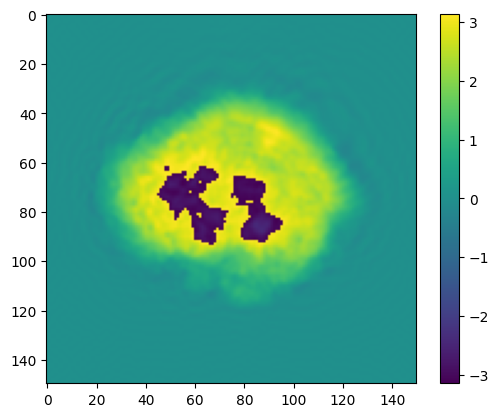

In [26]:
plt.imshow(np.angle(E_test[0]))
plt.colorbar()

In [27]:
maxiter = 250
lr_dRI = 5e-5
lr_q = 3e-6
lr_t = 1e-4
λ_TV = 1e-1
λ1_q = 5e1 
λ2_q = 5e1 

lr_dRI = 5.
lr_q = 1e0
lr_t = 1e3
λ_TV = 7e0
λ1_q = 5e0
λ2_q = 5e0 

#dRI = torch.tensor(dRI_GT_crop, dtype=torch.float32, requires_grad=True, device=DEV)
#Q = torch.tensor(Q_GT_new, requires_grad=True, device=DEV)
#T = torch.tensor(T_GT_new, requires_grad=True, device=DEV)

dRI = torch.zeros((N, N, N), dtype=torch.float32, requires_grad=True, device=DEV)
Q = torch.tensor(Q_start, dtype=torch.float32, requires_grad=True, device=DEV)
T = torch.tensor(T_start, dtype=torch.float32, requires_grad=True, device=DEV)

EM_trch = torch.tensor(EM_crop * np.exp(-1j * np.angle(EM_crop[:, :20, :20]).mean(axis=(1,2), keepdims=True)), requires_grad=False, device=DEV) 
errors = []

In [28]:
1e-1 * dRI.numel()

337500.0

In [29]:
i = 0
idx = np.random.permutation(200)
idx_b = idx[i * bs: (i+1) * bs]
Eb = forward_model(dRI, Q[idx_b], T[idx_b], K)
err_loc = loss_data(Eb, EM_trch[idx_b]) + λ_TV * loss_TV(dRI) + loss_smooth(Q, λ1_q, λ2_q)
err_loc.backward()
loss_data(Eb, EM_trch[idx_b]), λ_TV * loss_TV(dRI), loss_smooth(Q, λ1_q, λ2_q)

(tensor(0.8541, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(7.0000e-05, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(0.0018, device='cuda:0', grad_fn=<DivBackward0>))

In [30]:
for it in range(maxiter):

    idx = np.random.permutation(200)
    err = 0
    
    for i in range(200//bs):
            
        idx_b = idx[i * bs: (i+1) * bs]
        Eb = forward_model(dRI, Q[idx_b], T[idx_b], K)
        err_loc = loss_data(Eb, EM_trch[idx_b]) + λ_TV * loss_TV(dRI) + loss_smooth(Q, λ1_q, λ2_q)
        err_loc.backward()
        err += err_loc.item()
        #err_q = loss_smooth(Q, λ1_q, λ2_q)
        #err_q.backward()
        #err += err_q
        #err += err_loc

        with torch.no_grad():

            torch.clip(dRI - lr_dRI * dRI.grad, 0., 1., out=dRI)
            
            Q -= lr_q * Q.grad
            Q[:] = Q / torch.norm(Q, dim=1, keepdim=True)
            T -= lr_t * T.grad
            
            #print(torch.abs(dRI.grad).mean(), torch.abs(Q.grad).mean(), torch.abs(T.grad[:, :2]).mean(), torch.abs(T.grad[:, 2]).mean())

            dRI.grad = None
            Q.grad = None
            T.grad = None
     
        

    #err_q = λ_q * loss_smooth(Q)
    #err_q.backward()
    #err += err_q
    
    #with torch.no_grad():

    #    Q -= lr_q * Q.grad
    #    Q[:] = Q / torch.norm(Q, dim=1, keepdim=True)
    #    T -= lr_t * T.grad
        
    #    print(torch.abs(Q.grad).mean(), torch.abs(T.grad[:, :2]).mean(), torch.abs(T.grad[:, 2]).mean())

    #    Q.grad = None
    #    T.grad = None
    
    print(it, err)
    errors.append(err)
    

    

        
#432509.2500

0 8.58725069463253
1 2.3512651920318604
2 1.4799085520207882
3 1.1846938841044903
4 1.0333510898053646
5 0.9491013810038567
6 0.8951533064246178
7 0.8588465489447117
8 0.8326276950538158
9 0.8134493976831436
10 0.7994759939610958
11 0.7878484465181828
12 0.7778882421553135
13 0.7704510688781738
14 0.7629986330866814
15 0.7567780241370201
16 0.7516301237046719
17 0.7467127181589603
18 0.7423104047775269
19 0.7384013533592224
20 0.7346719242632389
21 0.7311798930168152
22 0.7285632789134979
23 0.7249390706419945
24 0.7225693240761757
25 0.7204534523189068
26 0.7174359485507011
27 0.715013213455677
28 0.7131616063416004
29 0.7109428495168686
30 0.7086778357625008
31 0.7071734964847565
32 0.7049090936779976
33 0.7032471895217896
34 0.7015606574714184
35 0.6996694914996624
36 0.6980291604995728
37 0.6969820596277714
38 0.6943427361547947
39 0.6929473876953125
40 0.6912269331514835
41 0.6900901161134243
42 0.6882251016795635
43 0.6875208579003811
44 0.6857146434485912
45 0.684371929615736
46

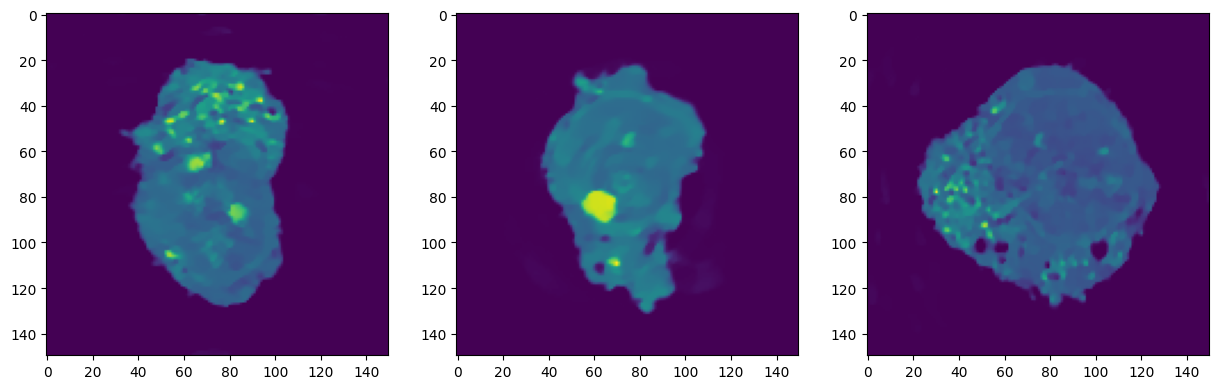

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dRI.cpu().detach().numpy()[N//2])

plt.subplot(132)
plt.imshow(dRI.cpu().detach().numpy()[:, N//2])

plt.subplot(133)
plt.imshow(dRI.cpu().detach().numpy()[:, :, N//2])


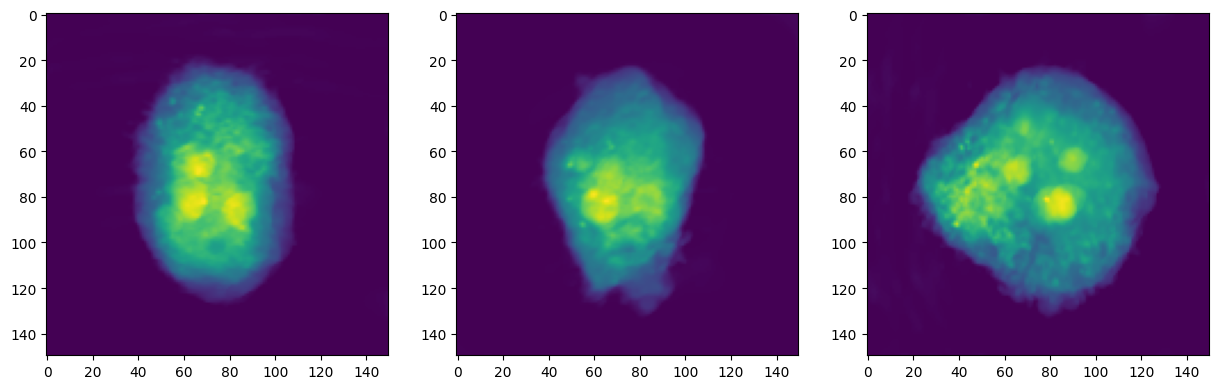

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=0))

plt.subplot(132)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=1))

plt.subplot(133)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=2))


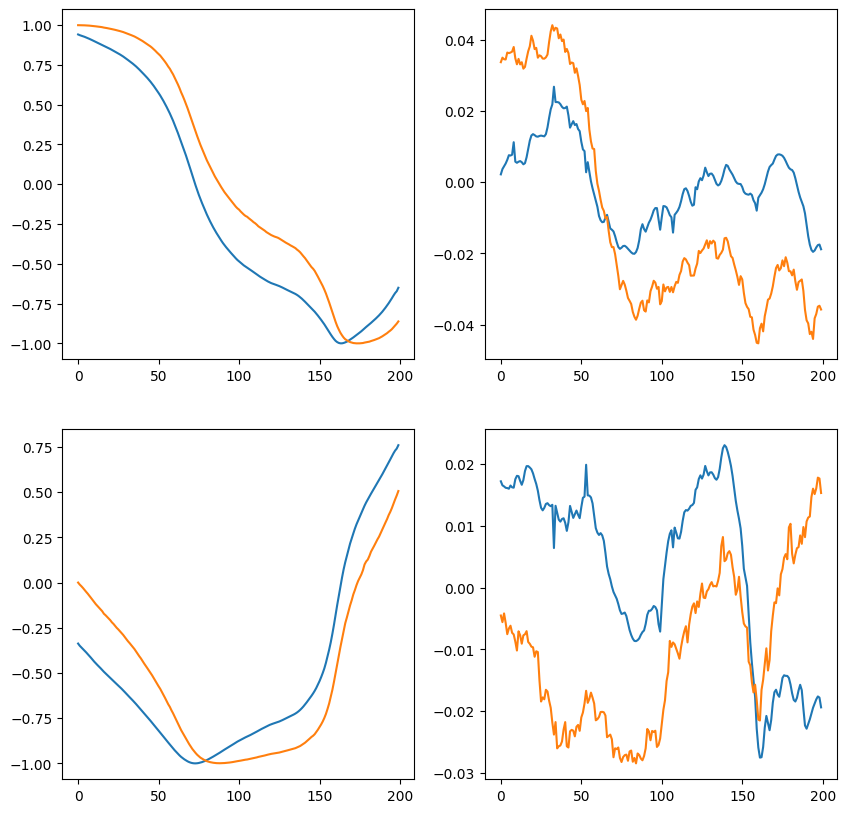

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(2, 2, 1+i)
    plt.plot(Q.cpu().detach().numpy()[:, i])
    plt.plot(Q_GT_new[:, i])

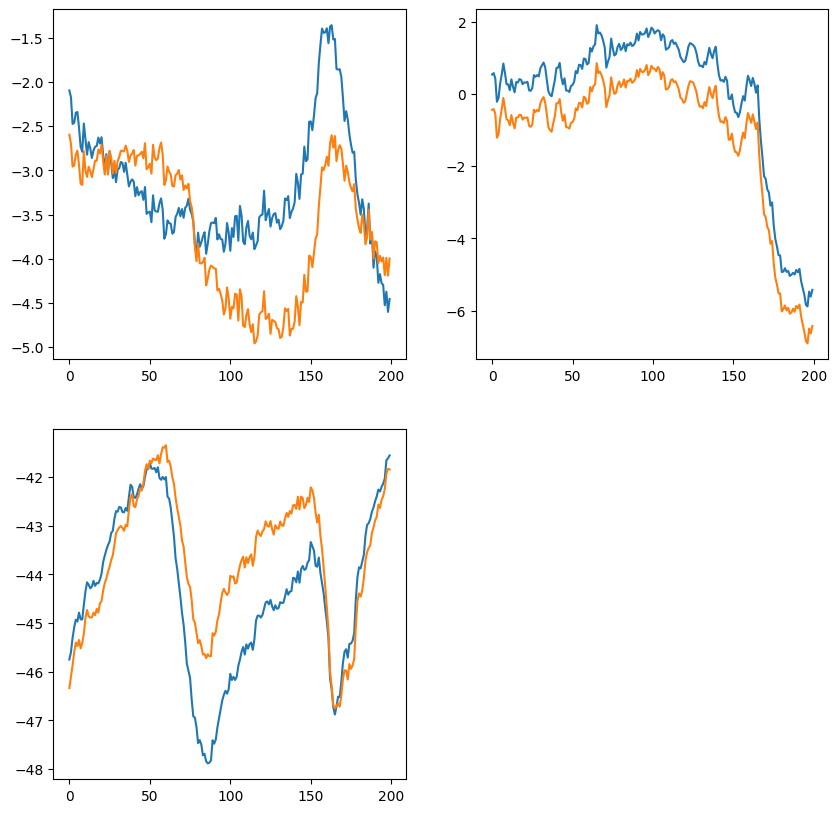

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(3):
    plt.subplot(2, 2, 1+i)
    plt.plot(T.cpu().detach().numpy()[:,i])
    plt.plot(T_GT_new[:,i])



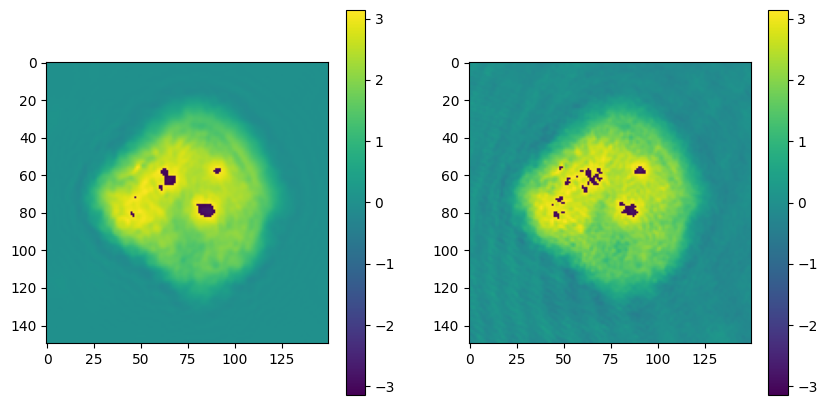

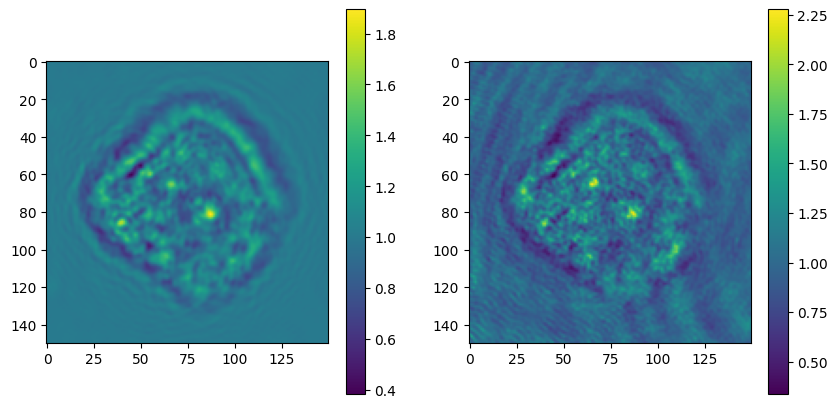

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(np.angle(Eb.cpu().detach().numpy()[0]))
plt.colorbar()
plt.subplot(122)
plt.imshow(np.angle(EM_trch.cpu().detach().numpy()[idx_b][0]))
plt.colorbar()

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(np.abs(Eb.cpu().detach().numpy()[0]))
plt.colorbar()
plt.subplot(122)
plt.imshow(np.abs(EM_trch.cpu().detach().numpy()[idx_b][0]))
plt.colorbar()